# Strategy Discovery: Weather Features for Corn Futures

**Goal**: Start from raw data — corn futures prices and Corn Belt weather — explore the relationship between weather and prices, and derive features that could be useful for a trading signal.

**Approach**:
1. Load raw data directly from the warehouse (no pre-built features)
2. Understand the data: what do prices and weather look like?
3. Look for patterns between weather conditions and price movements
4. Construct candidate features based on what we observe
5. Test which features carry useful information (and which don't)
6. Formulate and backtest a signal hypothesis
7. Compare against standard technical baselines
8. Conclude with feature catalog recommendations

**Data**: Daily corn futures (CBOT ZC=F) and Corn Belt daily precipitation and temperature (Iowa, Illinois, Nebraska), 2010-2026.

In [41]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sp_stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

from etl.db import load_prices, load_raw_data
from strategies.backtest import run_backtest

In [42]:
# Load corn futures prices directly from the warehouse
prices = load_prices('ZC=F')

# Load raw weather for each Corn Belt state
iowa = load_raw_data('weather_daily', 'state', 'Iowa').set_index('date').drop(columns=['state'])
illinois = load_raw_data('weather_daily', 'state', 'Illinois').set_index('date').drop(columns=['state'])
nebraska = load_raw_data('weather_daily', 'state', 'Nebraska').set_index('date').drop(columns=['state'])

# Corn Belt aggregate: simple mean across the three states
weather = pd.concat([iowa, illinois, nebraska]).groupby('date').mean()
weather.columns = ['temp_max', 'temp_min', 'precip']

print(f'Prices:  {len(prices):,} trading days, {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Weather: {len(weather):,} calendar days, {weather.index.min().date()} to {weather.index.max().date()}')
print(f'\nPrice columns: {list(prices.columns)}')
print(f'Weather columns: {list(weather.columns)}')

Prices:  4,068 trading days, 2010-01-04 to 2026-03-11
Weather: 5,913 calendar days, 2010-01-01 to 2026-03-10

Price columns: ['Open', 'High', 'Low', 'Close', 'Volume']
Weather columns: ['temp_max', 'temp_min', 'precip']


## 1. Raw Data Overview

Before constructing any features, look at what we have.

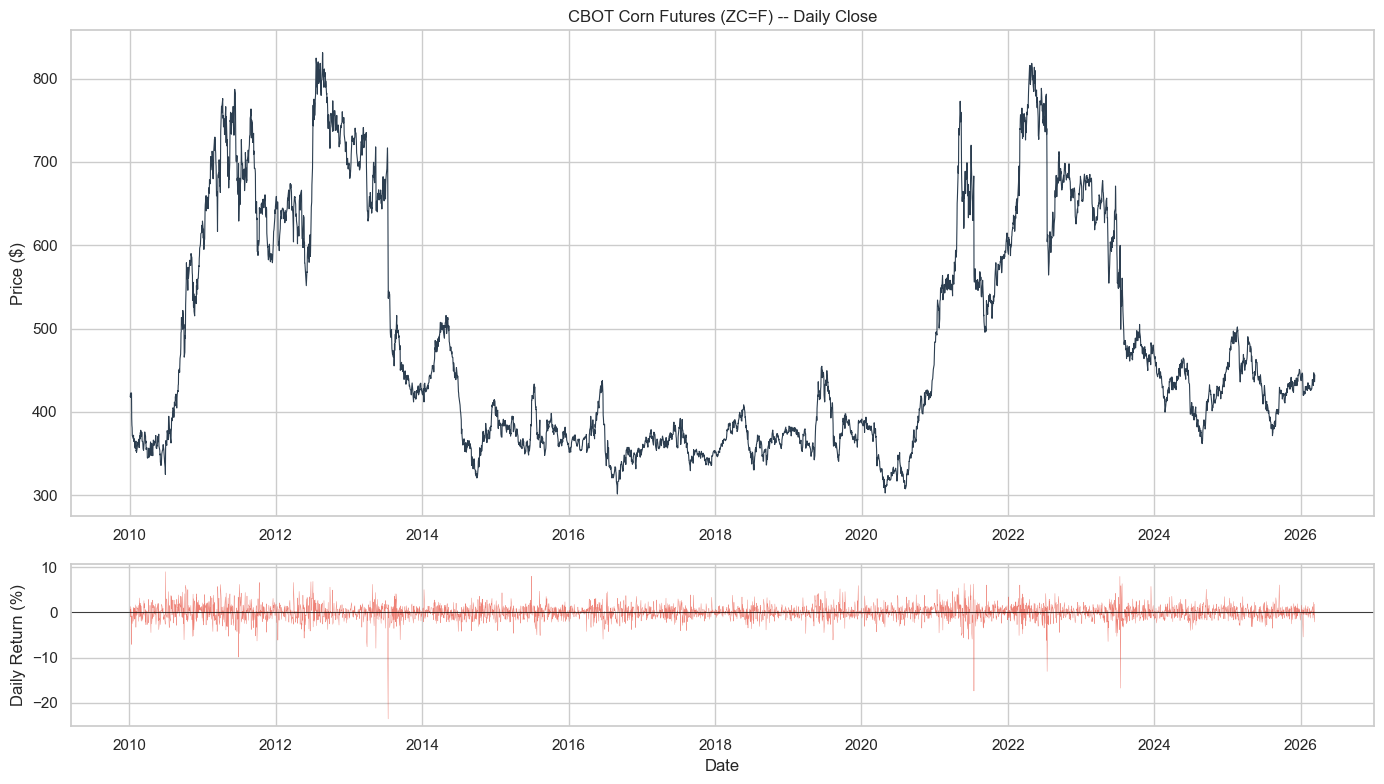

Mean daily return:     0.0164%
Median daily return:   0.0000%
Std daily return:      1.71%
Annualized volatility: 27.2%
Trading days:          4,068


In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(prices.index, prices['Close'], linewidth=0.8, color='#2c3e50')
axes[0].set_title('CBOT Corn Futures (ZC=F) -- Daily Close')
axes[0].set_ylabel('Price ($)')

daily_ret = prices['Close'].pct_change()

axes[1].plot(daily_ret.index, daily_ret * 100, linewidth=0.3, color='#e74c3c', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f'Mean daily return:     {daily_ret.mean()*100:.4f}%')
print(f'Median daily return:   {daily_ret.median()*100:.4f}%')
print(f'Std daily return:      {daily_ret.std()*100:.2f}%')
print(f'Annualized volatility: {daily_ret.std()*np.sqrt(252)*100:.1f}%')
print(f'Trading days:          {len(prices):,}')

## 2. Corn Belt Weather Patterns

What does the weather data actually look like? We summarize the key statistics
and seasonal structure before looking for relationships with prices.

In [4]:
# Summary statistics for the weather data
print('=== Corn Belt Weather Summary (3-state avg: Iowa, Illinois, Nebraska) ===')
print(f'Period: {weather.index.min().date()} to {weather.index.max().date()} ({len(weather):,} days)\n')

print('Daily precipitation (inches):')
print(f'  Mean:   {weather["precip"].mean():.3f}')
print(f'  Median: {weather["precip"].median():.3f}')
print(f'  Max:    {weather["precip"].max():.3f}')
print(f'  Dry days (<0.01 in): {(weather["precip"] < 0.01).sum():,} '
      f'({(weather["precip"] < 0.01).mean()*100:.1f}%)')

print(f'\nDaily max temperature (F):')
print(f'  Mean:   {weather["temp_max"].mean():.1f}')
print(f'  Min:    {weather["temp_max"].min():.1f}')
print(f'  Max:    {weather["temp_max"].max():.1f}')
print(f'  Days above 95F: {(weather["temp_max"] > 95).sum():,} '
      f'({(weather["temp_max"] > 95).mean()*100:.1f}%)')

print(f'\nDaily min temperature (F):')
print(f'  Mean:   {weather["temp_min"].mean():.1f}')
print(f'  Min:    {weather["temp_min"].min():.1f}')
print(f'  Max:    {weather["temp_min"].max():.1f}')
print(f'  Days below 32F: {(weather["temp_min"] < 32).sum():,} '
      f'({(weather["temp_min"] < 32).mean()*100:.1f}%)')

# Growing season vs off-season comparison
growing = weather[weather.index.month.isin([5, 6, 7, 8, 9])]
off = weather[~weather.index.month.isin([5, 6, 7, 8, 9])]

print(f'\n--- Growing Season (May-Sep) vs Off-Season ---')
print(f'  {"":20s} {"Growing":>10s} {"Off-Season":>12s}')
print(f'  {"Avg daily precip":20s} {growing["precip"].mean():>10.3f} {off["precip"].mean():>12.3f} in')
print(f'  {"Avg max temp":20s} {growing["temp_max"].mean():>10.1f} {off["temp_max"].mean():>12.1f} F')
print(f'  {"Avg min temp":20s} {growing["temp_min"].mean():>10.1f} {off["temp_min"].mean():>12.1f} F')
print(f'  {"Days":20s} {len(growing):>10,} {len(off):>12,}')

=== Corn Belt Weather Summary (3-state avg: Iowa, Illinois, Nebraska) ===
Period: 2010-01-01 to 2026-03-10 (5,913 days)

Daily precipitation (inches):
  Mean:   0.096
  Median: 0.012
  Max:    1.745
  Dry days (<0.01 in): 2,848 (48.2%)

Daily max temperature (F):
  Mean:   62.1
  Min:    -7.8
  Max:    102.3
  Days above 95F: 50 (0.8%)

Daily min temperature (F):
  Mean:   44.5
  Min:    -17.9
  Max:    83.7
  Days below 32F: 1,773 (30.0%)

--- Growing Season (May-Sep) vs Off-Season ---
                          Growing   Off-Season
  Avg daily precip          0.123        0.077 in
  Avg max temp               81.1         48.7 F
  Avg min temp               63.3         31.3 F
  Days                      2,448        3,465


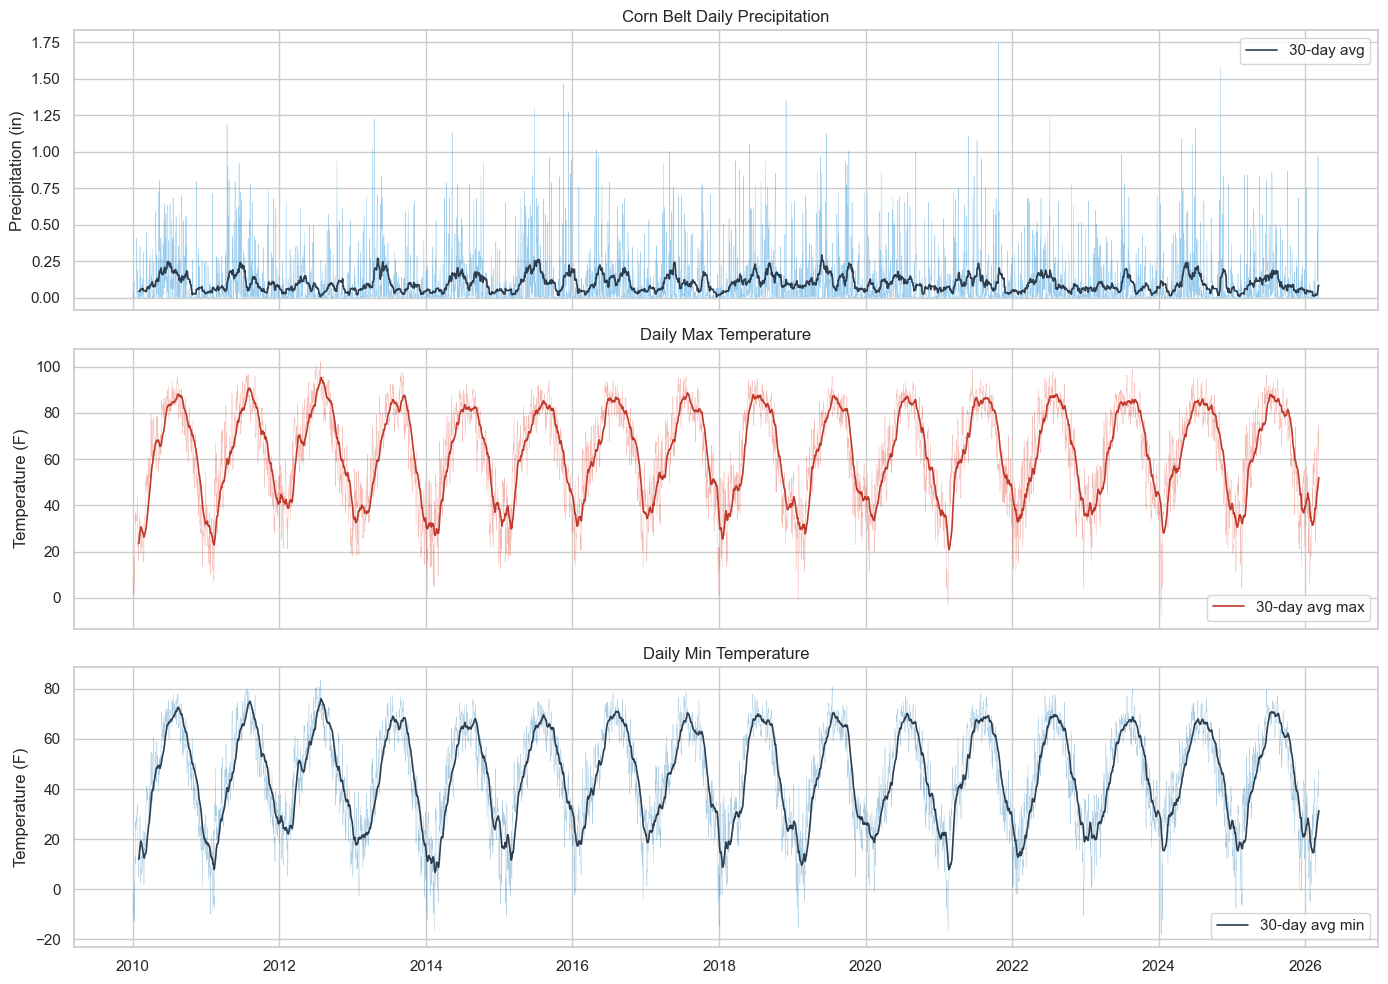

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weather.index, weather['precip'], linewidth=0.3, alpha=0.5, color='#3498db')
axes[0].plot(weather.index, weather['precip'].rolling(30).mean(), linewidth=1.2,
             color='#2c3e50', label='30-day avg')
axes[0].set_ylabel('Precipitation (in)')
axes[0].set_title('Corn Belt Daily Precipitation')
axes[0].legend()

axes[1].plot(weather.index, weather['temp_max'], linewidth=0.3, alpha=0.4, color='#e74c3c')
axes[1].plot(weather.index, weather['temp_max'].rolling(30).mean(), linewidth=1.2,
             color='#c0392b', label='30-day avg max')
axes[1].set_ylabel('Temperature (F)')
axes[1].set_title('Daily Max Temperature')
axes[1].legend()

axes[2].plot(weather.index, weather['temp_min'], linewidth=0.3, alpha=0.4, color='#2980b9')
axes[2].plot(weather.index, weather['temp_min'].rolling(30).mean(), linewidth=1.2,
             color='#2c3e50', label='30-day avg min')
axes[2].set_ylabel('Temperature (F)')
axes[2].set_title('Daily Min Temperature')
axes[2].legend()

plt.tight_layout()
plt.show()

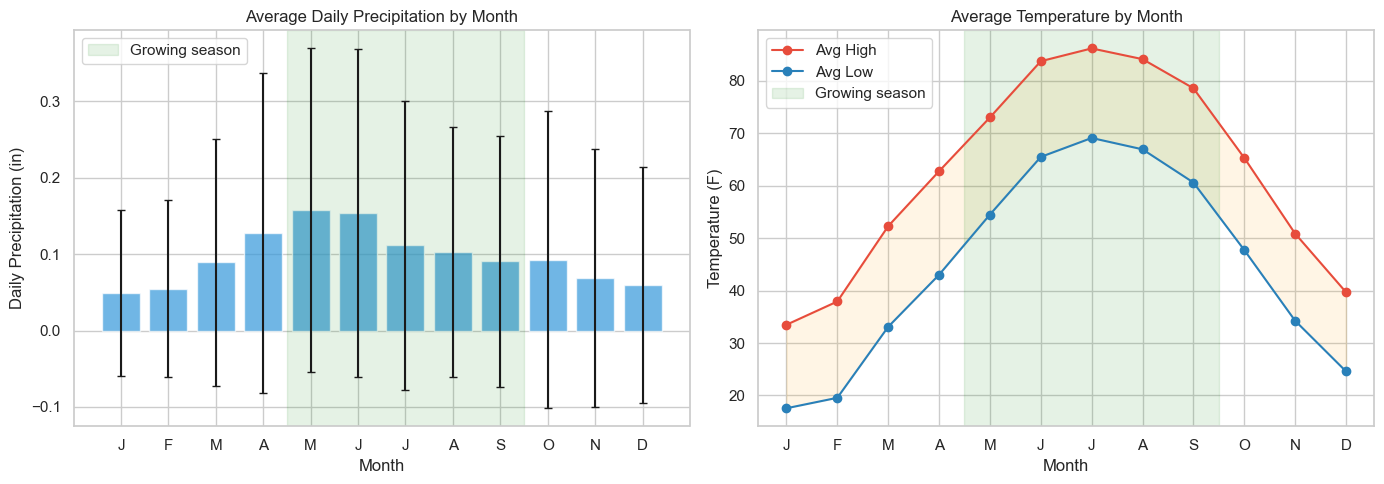

In [6]:
monthly = weather.copy()
monthly['month'] = monthly.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precipitation by month
month_precip = monthly.groupby('month')['precip'].agg(['mean', 'std'])
axes[0].bar(range(1, 13), month_precip['mean'], yerr=month_precip['std'],
            color='#3498db', alpha=0.7, capsize=3)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Daily Precipitation (in)')
axes[0].set_title('Average Daily Precipitation by Month')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].axvspan(4.5, 9.5, alpha=0.1, color='green', label='Growing season')
axes[0].legend()

# Temperature by month
month_temp = monthly.groupby('month')[['temp_max', 'temp_min']].mean()
axes[1].plot(range(1, 13), month_temp['temp_max'], 'o-', color='#e74c3c', label='Avg High')
axes[1].plot(range(1, 13), month_temp['temp_min'], 'o-', color='#2980b9', label='Avg Low')
axes[1].fill_between(range(1, 13), month_temp['temp_min'], month_temp['temp_max'],
                     alpha=0.1, color='orange')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Temperature (F)')
axes[1].set_title('Average Temperature by Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].axvspan(4.5, 9.5, alpha=0.1, color='green', label='Growing season')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Weather x Futures: Looking for Patterns

The central question: does weather data carry information about where corn prices
are going? We align the two datasets and look for relationships.

In [7]:
# Align weather to trading days (futures only trade on business days)
df = prices[['Close']].copy()
df = df.join(weather, how='left')
df[['precip', 'temp_max', 'temp_min']] = df[['precip', 'temp_max', 'temp_min']].ffill()

# Forward price changes in dollars. With Panama-adjusted data, dollar changes
# (diff) are the correct measure -- they are preserved exactly by the absolute
# shift method. Percentage returns (pct_change) are distorted and should not
# be used.
df['chg_1d'] = df['Close'].diff(1).shift(-1)
df['chg_5d'] = df['Close'].diff(5).shift(-5)
df['chg_20d'] = df['Close'].diff(20).shift(-20)

print(f'Combined dataset: {len(df):,} rows')
print(f'\nForward price change stats ($):')
summary = pd.DataFrame({
    'mean': df[['chg_1d', 'chg_5d', 'chg_20d']].mean(),
    'median': df[['chg_1d', 'chg_5d', 'chg_20d']].median(),
    'std': df[['chg_1d', 'chg_5d', 'chg_20d']].std(),
    'count': df[['chg_1d', 'chg_5d', 'chg_20d']].count(),
})
print(summary.round(2).to_string())
df.head()

Combined dataset: 4,068 rows

Forward price change stats ($):
         mean  median    std  count
chg_1d   0.13    0.00   8.68   4067
chg_5d   0.63    0.75  19.28   4063
chg_20d  2.68    2.25  37.38   4048


,Close,temp_max,temp_min,precip,chg_1d,chg_5d,chg_20d
date,,,,,,,
2010-01-04,-75.75,5.48,-7.18,0.000000,0.25,4.00,-53.50
2010-01-05,-75.50,7.58,-6.28,0.000000,3.00,-26.25,-65.75
2010-01-06,-72.50,17.30,-0.22,0.108924,-4.25,-37.75,-67.75
2010-01-07,-76.75,12.32,3.14,0.108924,5.50,-36.50,-66.00
2010-01-08,-71.25,5.18,-4.54,0.002625,-0.50,-51.50,-67.00


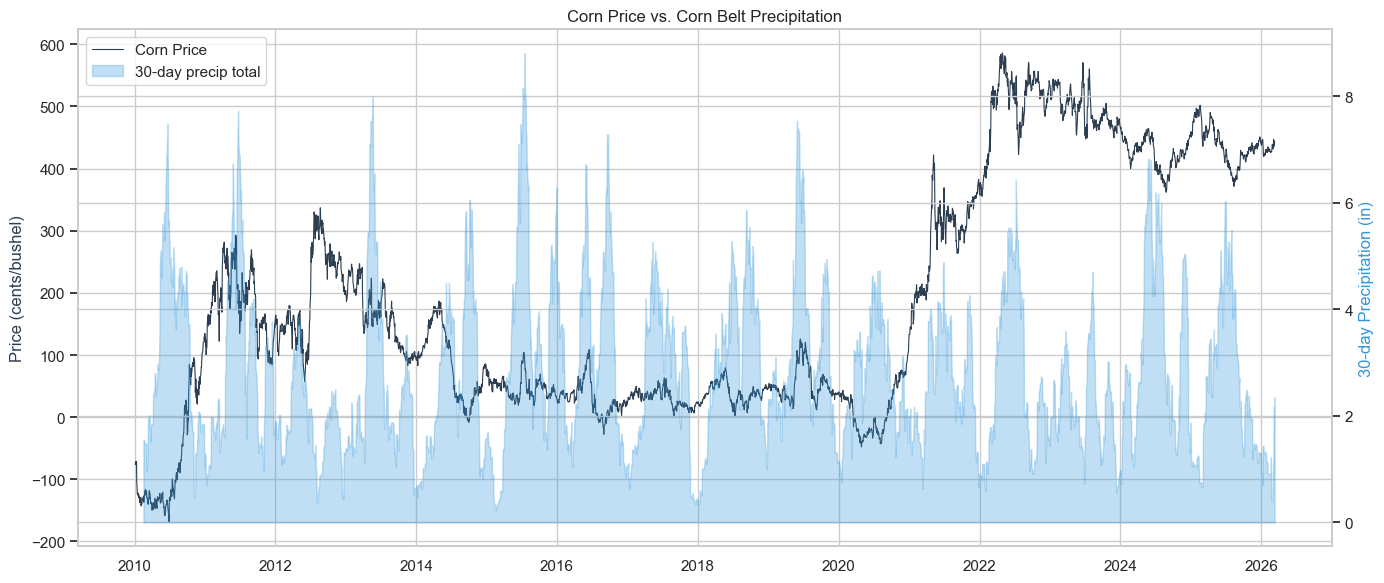

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df.index, df['Close'], linewidth=0.8, color='#2c3e50', label='Corn Price')
ax1.set_ylabel('Price (cents/bushel)', color='#2c3e50')

ax2 = ax1.twinx()
precip_30d = df['precip'].rolling(30).sum()
ax2.fill_between(df.index, precip_30d, alpha=0.3, color='#3498db', label='30-day precip total')
ax2.set_ylabel('30-day Precipitation (in)', color='#3498db')

ax1.set_title('Corn Price vs. Corn Belt Precipitation')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 3b. Scatter plots: which precipitation window correlates with price changes?

We compute rolling precipitation sums at 7, 14, 30, and 60-day windows and scatter
each against the 20-day forward price change. The goal is to see if any window shows
a clear relationship, and to check whether that relationship is linear or nonlinear.

### 3a. Visual overlay: price vs. precipitation

Do they move together? A visual check before running any statistics. We overlay the
30-day cumulative precipitation on the price chart to see if there's any visible
co-movement or if price spikes coincide with weather extremes.

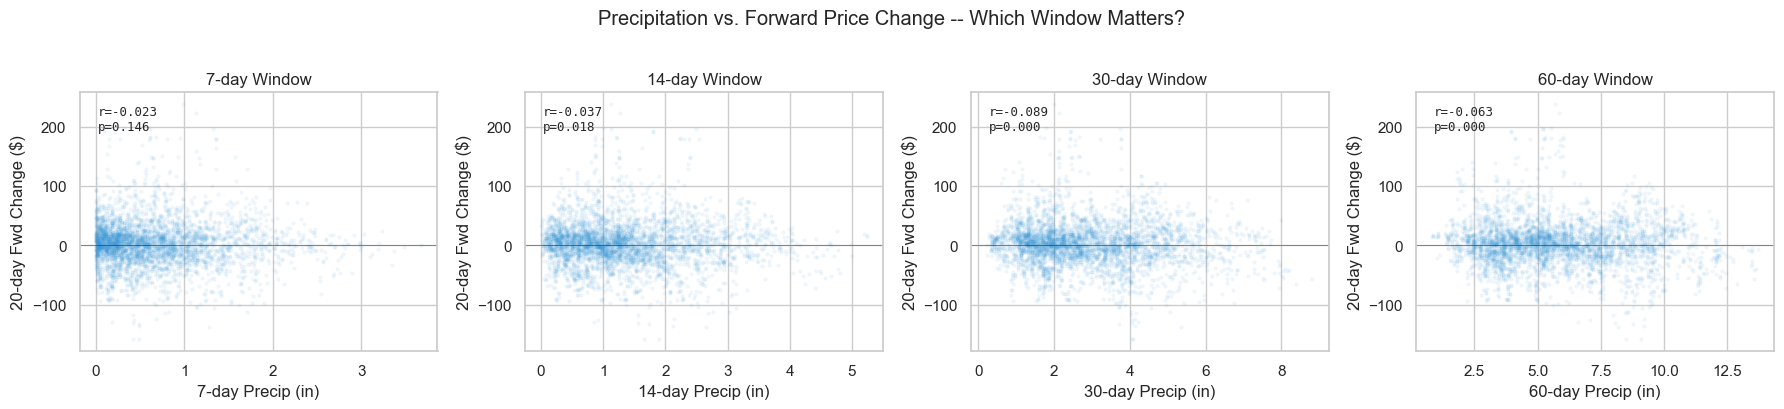

In [9]:
# How does precipitation at different rolling windows relate to forward price changes?
windows = [7, 14, 30, 60]
fig, axes = plt.subplots(1, len(windows), figsize=(18, 4))

for i, w in enumerate(windows):
    col = f'precip_{w}d_raw'
    df[col] = df['precip'].rolling(w).sum().shift(1)  # shift(1) for point-in-time
    valid = df[[col, 'chg_20d']].dropna()

    axes[i].scatter(valid[col], valid['chg_20d'], alpha=0.05, s=5, color='#3498db')
    axes[i].set_xlabel(f'{w}-day Precip (in)')
    axes[i].set_ylabel('20-day Fwd Change ($)')
    axes[i].set_title(f'{w}-day Window')
    axes[i].axhline(0, color='black', linewidth=0.5, alpha=0.5)

    if len(valid) > 2:
        r, p = sp_stats.pearsonr(valid[col], valid['chg_20d'])
        axes[i].text(0.05, 0.95, f'r={r:.3f}\np={p:.3f}', transform=axes[i].transAxes,
                     va='top', fontsize=9, family='monospace')

plt.suptitle('Precipitation vs. Forward Price Change -- Which Window Matters?', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Linear correlations between raw precipitation and returns are weak, which is expected.
Weather does not affect prices linearly. A drought (too little rain) and a flood (too
much rain) both hurt crops and push prices *up*. Normal weather means normal supply
and no price pressure.

This means we should look at **extremes and anomalies** rather than raw levels. Below
we construct several candidate features from the raw data and measure their relationship
to returns using both Pearson correlation (linear) and **mutual information** (captures
any statistical dependency, including nonlinear).

In [10]:
# ---- Precipitation features ----

# Rolling sums at different horizons
df['precip_7d'] = df['precip'].rolling(7).sum().shift(1)
df['precip_14d'] = df['precip'].rolling(14).sum().shift(1)
df['precip_30d'] = df['precip'].rolling(30).sum().shift(1)

# Z-scores: how abnormal is recent precipitation vs. a rolling baseline?
for w in [30, 60, 90]:
    rolling_mean = df['precip'].rolling(w).mean()
    rolling_std = df['precip'].rolling(w).std()
    df[f'precip_zscore_{w}d'] = ((df['precip'] - rolling_mean) / rolling_std).shift(1)

# Dry-day streak: consecutive days with < 0.01 inches of rain
dry = (df['precip'] < 0.01).astype(int)
df['dry_streak'] = dry.groupby((dry != dry.shift()).cumsum()).cumsum().shift(1)

# ---- Temperature features ----

df['temp_range'] = df['temp_max'] - df['temp_min']
df['temp_max_7d'] = df['temp_max'].rolling(7).mean().shift(1)
df['temp_max_30d'] = df['temp_max'].rolling(30).mean().shift(1)

# Heat stress: days above 95F in the last 7 days
df['heat_days_7d'] = (df['temp_max'] > 95).astype(int).rolling(7).sum().shift(1)

# ---- Combined feature ----

# Drought index: high when precipitation is abnormally low AND temperature is high
df['drought_index'] = (
    -df['precip_zscore_30d'].clip(upper=0) *  # more negative z = drier
    (df['temp_max_7d'] / df['temp_max_7d'].median())  # scaled by temp relative to median
)

feature_cols = [
    'precip_7d', 'precip_14d', 'precip_30d',
    'precip_zscore_30d', 'precip_zscore_60d', 'precip_zscore_90d',
    'dry_streak', 'temp_max_7d', 'temp_max_30d', 'temp_range',
    'heat_days_7d', 'drought_index',
]

print(f'Built {len(feature_cols)} candidate features from raw data')
df[feature_cols].describe().round(3)

Built 12 candidate features from raw data


,precip_7d,precip_14d,precip_30d,precip_zscore_30d,precip_zscore_60d,precip_zscore_90d,dry_streak,temp_max_7d,temp_max_30d,temp_range,heat_days_7d,drought_index
count,4061.000,4054.000,4038.000,4038.000,4008.000,3978.000,4067.000,4061.000,4038.000,4068.000,4061.000,4038.000
mean,0.664,1.327,2.848,0.010,0.017,0.013,1.334,62.438,62.576,17.620,0.072,0.341
std,0.587,0.919,1.541,1.013,1.038,1.038,2.141,19.525,18.411,5.112,0.436,0.312
min,0.000,0.005,0.226,-1.075,-0.932,-0.823,0.000,8.051,24.098,2.520,0.000,-0.000
25%,0.207,0.622,1.671,-0.546,-0.542,-0.546,0.000,45.783,45.201,14.220,0.000,0.000
50%,0.512,1.142,2.526,-0.405,-0.406,-0.419,0.000,64.683,64.903,17.520,0.000,0.291
75%,0.957,1.841,3.869,0.128,0.114,0.110,2.000,80.651,80.642,20.820,0.000,0.560
max,3.677,5.239,8.815,5.003,6.885,7.129,17.000,98.171,94.654,39.900,7.000,1.373


### 4a. Constructing candidate features

We build features in three categories from raw data:

- **Precipitation features**: rolling sums (how much rain fell recently), z-scores
  (how unusual is recent rain vs. history), and dry-day streaks.
- **Temperature features**: rolling averages, diurnal range, and heat stress counts.
- **Combined features**: drought index that multiplies low-precipitation anomaly by
  high temperature -- the hypothesis being that hot + dry is worse than either alone.

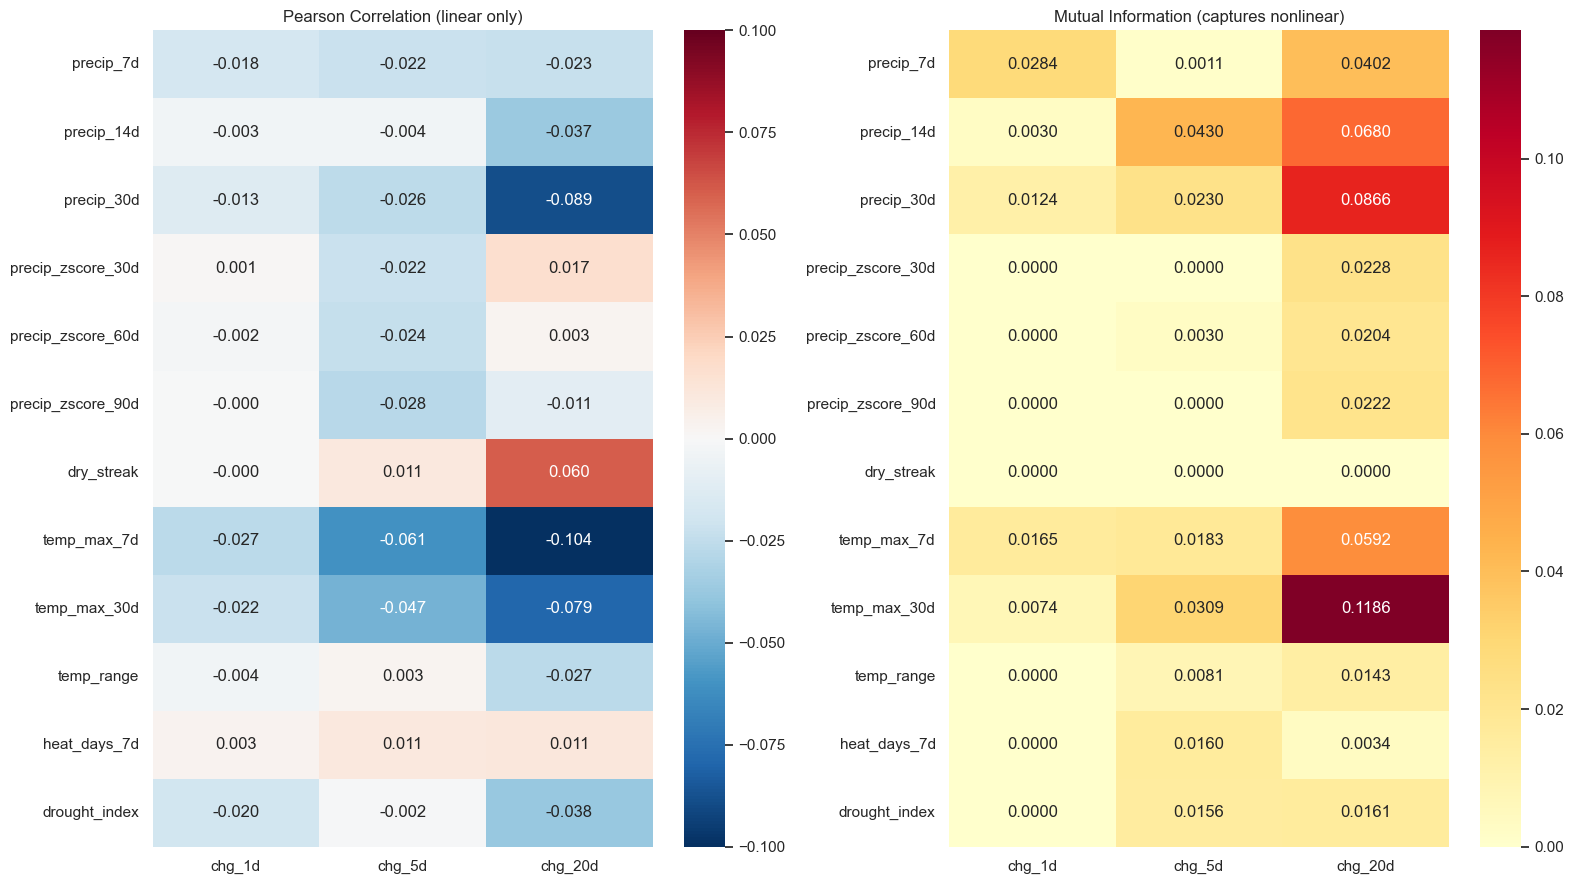

Left panel: Pearson r is near zero for most features. This does NOT mean
there is no relationship -- it means the relationship is not linear.

Right panel: MI scores show which features carry the most total information
about price changes. Higher = more predictive (in any direction/shape).
Features with low Pearson but higher MI likely have a nonlinear relationship.


In [11]:
# --- Why two methods? ---
# Pearson correlation only captures LINEAR relationships. If both drought
# (low precip) and flood (high precip) push prices up, the linear correlation
# cancels out and shows near-zero -- even though there IS a relationship.
#
# Mutual information (MI) measures ANY statistical dependence, including
# nonlinear and U-shaped relationships. A higher MI value means the feature
# carries more information about the target, regardless of the shape.

from sklearn.feature_selection import mutual_info_regression

change_cols = ['chg_1d', 'chg_5d', 'chg_20d']

# --- Linear correlation ---
corr = df[feature_cols + change_cols].corr().loc[feature_cols, change_cols]

# --- Mutual information ---
mi_results = pd.DataFrame(index=feature_cols, columns=change_cols, dtype=float)
for cc in change_cols:
    for fc in feature_cols:
        subset = df[[fc, cc]].dropna()
        if len(subset) < 100:
            mi_results.loc[fc, cc] = 0.0
            continue
        mi = mutual_info_regression(
            subset[[fc]], subset[cc], random_state=42, n_neighbors=5
        )
        mi_results.loc[fc, cc] = mi[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.1, vmax=0.1, ax=axes[0])
axes[0].set_title('Pearson Correlation (linear only)')

sns.heatmap(mi_results.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, ax=axes[1])
axes[1].set_title('Mutual Information (captures nonlinear)')

plt.tight_layout()
plt.show()

print('Left panel: Pearson r is near zero for most features. This does NOT mean')
print('there is no relationship -- it means the relationship is not linear.')
print()
print('Right panel: MI scores show which features carry the most total information')
print('about price changes. Higher = more predictive (in any direction/shape).')
print('Features with low Pearson but higher MI likely have a nonlinear relationship.')

### 4b. Measuring feature-return dependence: correlation vs. mutual information

Two ways to measure whether a feature is related to future price changes:

1. **Pearson correlation** measures linear dependence. If the relationship is "more X
   means higher returns," Pearson will catch it. But if the relationship is nonlinear
   (e.g. both very low AND very high precipitation push prices up), the positive and
   negative effects cancel out and Pearson shows ~0.

2. **Mutual information (MI)** measures total statistical dependence regardless of shape.
   It answers: "does knowing this feature's value reduce my uncertainty about the price
   change?" A higher MI means the feature carries more information. MI = 0 means the
   feature and target are statistically independent.

## 5. Testing Extreme Weather Conditions

Linear correlation fails here because the weather-price relationship is fundamentally
nonlinear: both tails (drought and flood) affect supply negatively. We need to look at
what happens to returns *conditioned on* extreme weather.

This is a key difference between ML model evaluation and trading signal evaluation:

- In ML, you check prediction accuracy against a labeled test set.
- In trading, there is no labeled "right answer." You measure whether entering a
  position when conditions are met produces positive expected value after costs
  and risk adjustment.
- A signal can be wrong most of the time and still make money, if the wins are
  large enough to offset the losses.
- With ~4,000 trading days, overfitting is the primary risk. A model that memorizes
  noise will look great in-sample and fail out-of-sample.
- We need a causal story: "drought hurts yield, lower supply pushes prices up" is
  testable and durable. "Feature #47 has p=0.03" is not.

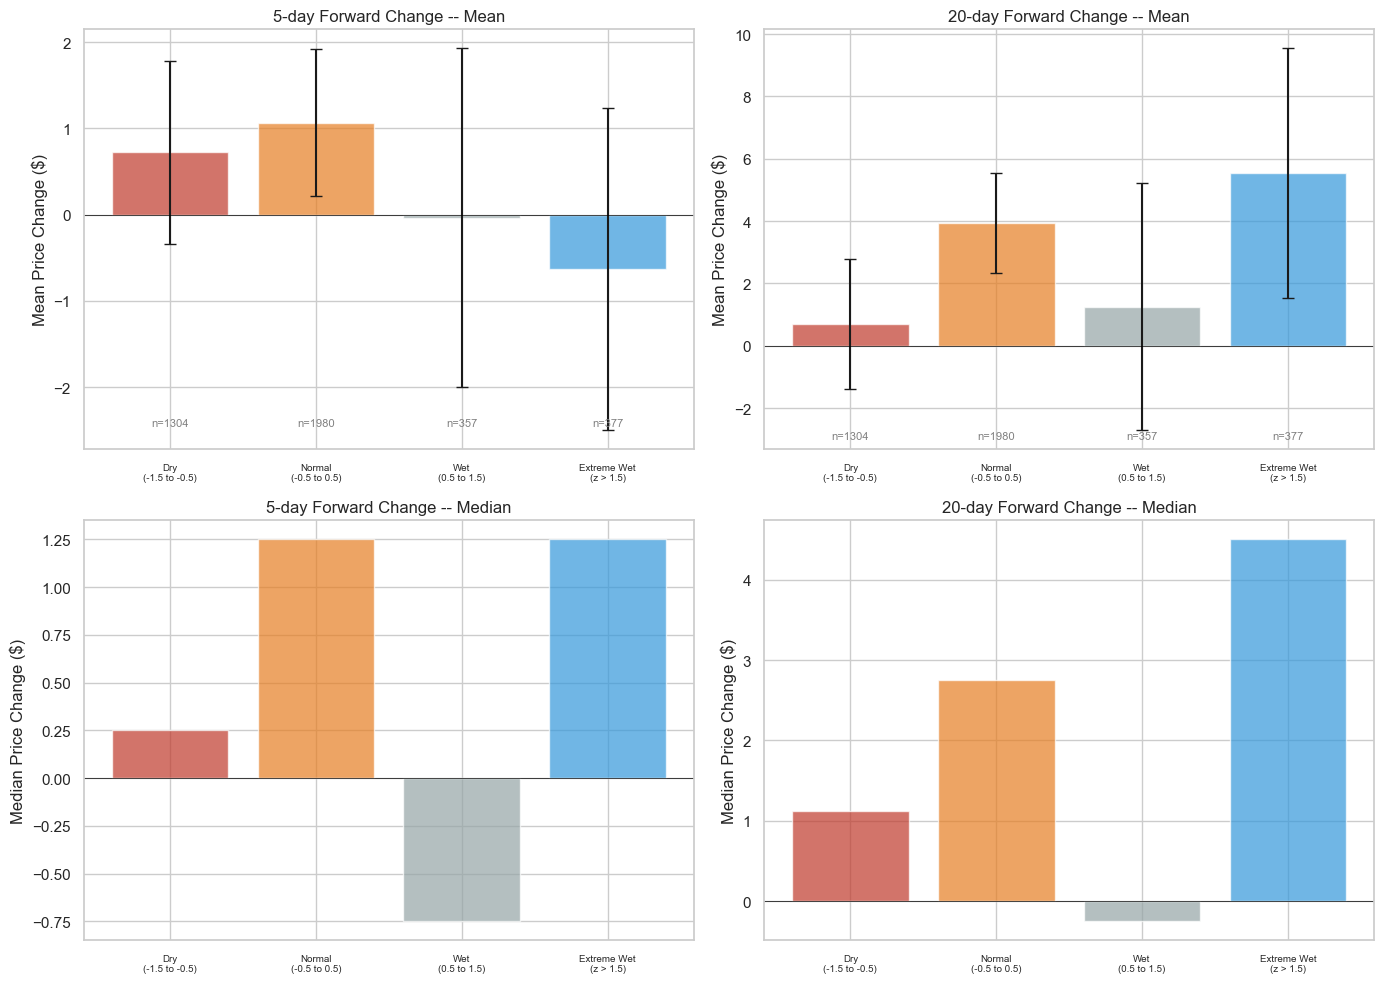

Top row: mean (includes all observations). Bottom row: median (robust).
Compare both to judge the pattern.


In [12]:
# Bin days by their precipitation z-score and measure the average
# forward price change in each bin. If extreme weather zones show
# meaningfully different price behavior than normal, that's a signal.

analysis = df[['precip_zscore_30d', 'chg_5d', 'chg_20d']].dropna()

bins = [-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
labels = ['Extreme Dry\n(z < -1.5)', 'Dry\n(-1.5 to -0.5)', 'Normal\n(-0.5 to 0.5)',
          'Wet\n(0.5 to 1.5)', 'Extreme Wet\n(z > 1.5)']
analysis['zone'] = pd.cut(analysis['precip_zscore_30d'], bins=bins, labels=labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_i, chg_col in enumerate(['chg_5d', 'chg_20d']):
    horizon = '5-day' if chg_col == 'chg_5d' else '20-day'
    zone_chg = analysis.groupby('zone', observed=True)[chg_col].agg(['mean', 'median', 'std', 'count'])
    zone_chg['se'] = zone_chg['std'] / np.sqrt(zone_chg['count'])

    colors = ['#c0392b', '#e67e22', '#95a5a6', '#3498db', '#2c3e50']

    # Mean
    axes[0, col_i].bar(range(len(zone_chg)), zone_chg['mean'],
                yerr=zone_chg['se'] * 1.96, capsize=4,
                color=colors, alpha=0.7)
    axes[0, col_i].set_xticks(range(len(zone_chg)))
    axes[0, col_i].set_xticklabels(zone_chg.index, fontsize=7)
    axes[0, col_i].axhline(0, color='black', linewidth=0.5)
    axes[0, col_i].set_ylabel('Mean Price Change ($)')
    axes[0, col_i].set_title(f'{horizon} Forward Change -- Mean')
    for j, (_, row) in enumerate(zone_chg.iterrows()):
        axes[0, col_i].text(j, axes[0, col_i].get_ylim()[0] * 0.9,
                     f'n={int(row["count"])}', ha='center', fontsize=8, color='gray')

    # Median
    axes[1, col_i].bar(range(len(zone_chg)), zone_chg['median'],
                color=colors, alpha=0.7)
    axes[1, col_i].set_xticks(range(len(zone_chg)))
    axes[1, col_i].set_xticklabels(zone_chg.index, fontsize=7)
    axes[1, col_i].axhline(0, color='black', linewidth=0.5)
    axes[1, col_i].set_ylabel('Median Price Change ($)')
    axes[1, col_i].set_title(f'{horizon} Forward Change -- Median')

plt.tight_layout()
plt.show()

print('Top row: mean (includes all observations). Bottom row: median (robust).')
print('Compare both to judge the pattern.')

### 5a. Conditional price changes by precipitation zone

Instead of asking "what is the correlation?", we ask a more direct question: "when
precipitation is extremely low, what happens to prices over the next 5 and 20 days?"

We bin days into five zones based on the 30-day precipitation z-score, then compute
the average forward price change in each zone. If extreme zones show meaningfully
different behavior from the normal zone, that is a potential signal.

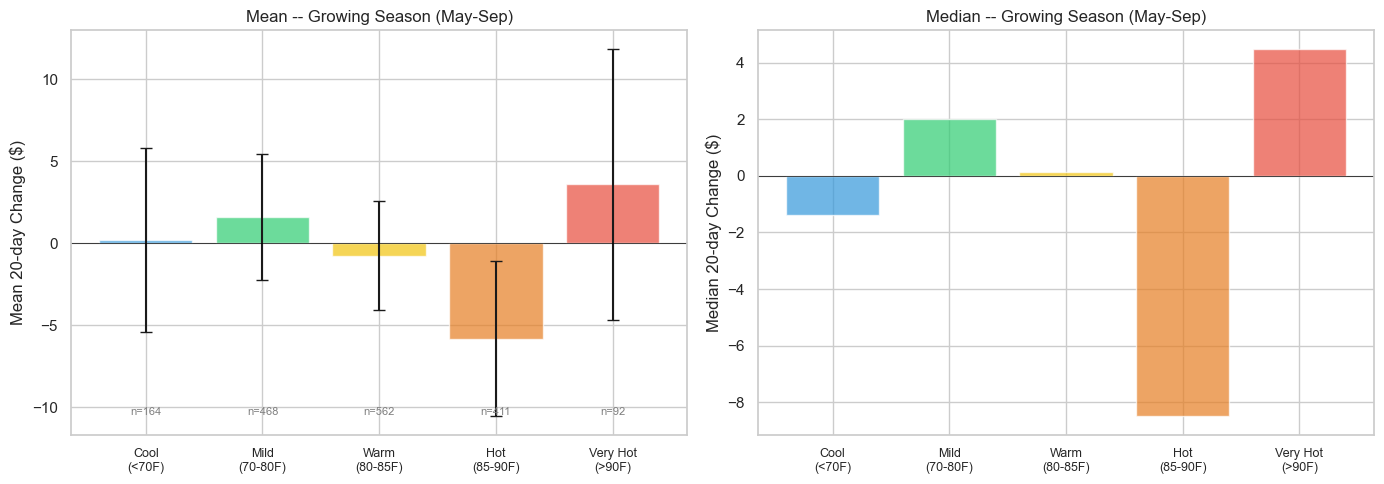

In [13]:
# Same analysis for temperature, but restricted to the growing season (May-Sep)
# when temperature actually affects the crop.

analysis_t = df[['temp_max_7d', 'chg_20d']].dropna()
growing = analysis_t[analysis_t.index.month.isin([5, 6, 7, 8, 9])].copy()

bins_t = [0, 70, 80, 85, 90, 120]
labels_t = ['Cool\n(<70F)', 'Mild\n(70-80F)', 'Warm\n(80-85F)',
            'Hot\n(85-90F)', 'Very Hot\n(>90F)']
growing['temp_zone'] = pd.cut(growing['temp_max_7d'], bins=bins_t, labels=labels_t)

zone_chg = growing.groupby('temp_zone', observed=True)['chg_20d'].agg(['mean', 'median', 'std', 'count'])
zone_chg['se'] = zone_chg['std'] / np.sqrt(zone_chg['count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_t = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

axes[0].bar(range(len(zone_chg)), zone_chg['mean'],
       yerr=zone_chg['se'] * 1.96, capsize=4, color=colors_t, alpha=0.7)
axes[0].set_xticks(range(len(zone_chg)))
axes[0].set_xticklabels(zone_chg.index, fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Mean 20-day Change ($)')
axes[0].set_title('Mean -- Growing Season (May-Sep)')
for j, (_, row) in enumerate(zone_chg.iterrows()):
    axes[0].text(j, axes[0].get_ylim()[0] * 0.9, f'n={int(row["count"])}',
            ha='center', fontsize=8, color='gray')

axes[1].bar(range(len(zone_chg)), zone_chg['median'],
       color=colors_t, alpha=0.7)
axes[1].set_xticks(range(len(zone_chg)))
axes[1].set_xticklabels(zone_chg.index, fontsize=9)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Median 20-day Change ($)')
axes[1].set_title('Median -- Growing Season (May-Sep)')

plt.tight_layout()
plt.show()

### 5b. Temperature conditional analysis (growing season only)

Temperature should only matter during the growing season (May-September) when corn
is actively developing. Extreme heat during pollination (July-August) can permanently
reduce yield. We check whether hot-temperature days show different forward price
behavior than mild-temperature days.

In [14]:
# Does combining precipitation and temperature give a stronger signal?
# Hypothesis: drought stress = dry weather + hot temperatures should be
# the strongest supply-threat scenario.

combo = df[['precip_zscore_30d', 'temp_max_7d', 'chg_20d']].dropna()
combo = combo[combo.index.month.isin([5, 6, 7, 8, 9])].copy()  # growing season

combo['precip_regime'] = 'normal'
combo.loc[combo['precip_zscore_30d'] < -0.8, 'precip_regime'] = 'dry'
combo.loc[combo['precip_zscore_30d'] > 1.5, 'precip_regime'] = 'wet'

combo['temp_regime'] = 'normal'
combo.loc[combo['temp_max_7d'] > 85, 'temp_regime'] = 'hot'
combo.loc[combo['temp_max_7d'] < 70, 'temp_regime'] = 'cool'

pivot = combo.groupby(['precip_regime', 'temp_regime'])['chg_20d'].agg(['mean', 'median', 'count'])

print('20-day Forward Price Change ($) by Weather Regime  [Growing Season]')
print('=' * 70)
print(pivot.round(2).to_string())

if len(pivot) > 0:
    best = pivot['median'].idxmax()
    worst = pivot['median'].idxmin()
    print(f'\nHighest median change: {best[0]} precip + {best[1]} temp '
          f'(median ${pivot.loc[best, "median"]:.2f}, '
          f'mean ${pivot.loc[best, "mean"]:.2f}, '
          f'n={int(pivot.loc[best, "count"])})')
    print(f'Lowest median change:  {worst[0]} precip + {worst[1]} temp '
          f'(median ${pivot.loc[worst, "median"]:.2f}, '
          f'mean ${pivot.loc[worst, "mean"]:.2f}, '
          f'n={int(pivot.loc[worst, "count"])})')

20-day Forward Price Change ($) by Weather Regime  [Growing Season]
                            mean  median  count
precip_regime temp_regime                      
dry           cool          8.56    7.62      4
              hot         -18.40   -2.62     22
              normal        0.20    9.25     81
normal        cool         -1.64   -2.12    144
              hot          -3.86   -7.75    431
              normal       -0.03   -0.25    859
wet           cool         14.47   12.38     16
              hot           0.12   -5.38     50
              normal        3.64    7.12     90

Highest median change: wet precip + cool temp (median $12.38, mean $14.47, n=16)
Lowest median change:  normal precip + hot temp (median $-7.75, mean $-3.86, n=431)


### 5c. Interaction: precipitation x temperature

Do the two weather variables interact? Specifically, is the combination of dry + hot
worse for crops (and therefore more price-moving) than either condition alone? We cross
precipitation and temperature regimes to check.

## 6. Threshold Sensitivity

A common trap in strategy development is finding thresholds that fit the data perfectly
but do not generalize. We want to check whether the precipitation anomaly pattern holds
across a reasonable range of threshold values, not just one lucky pair.

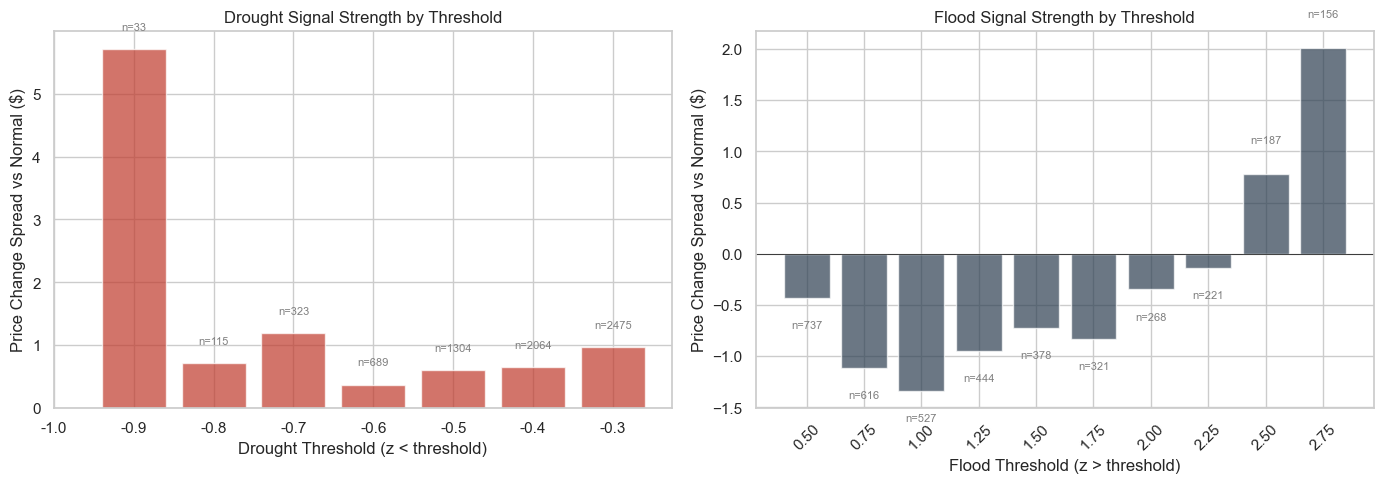

If the spread is consistently positive across a range of thresholds,
the pattern is robust -- not dependent on picking one lucky cutoff.


In [15]:
# Sweep through different z-score thresholds and measure the average
# 5-day forward price change for days below/above that threshold, minus
# the average change on "normal" days. A positive spread means extreme
# weather days see larger price increases than normal days.

drought_thresholds = np.arange(-1.0, -0.2, 0.1)
flood_thresholds = np.arange(0.5, 3.0, 0.25)

valid_sweep = df[['precip_zscore_30d', 'chg_5d']].dropna()
chg_normal = valid_sweep.loc[
    (valid_sweep['precip_zscore_30d'] > -0.3) & (valid_sweep['precip_zscore_30d'] < 0.3),
    'chg_5d'
].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drought threshold sweep
drought_spreads = []
for t in drought_thresholds:
    mask = valid_sweep['precip_zscore_30d'] < t
    n = mask.sum()
    chg = valid_sweep.loc[mask, 'chg_5d'].mean() if n > 10 else np.nan
    spread = chg - chg_normal if pd.notna(chg) else np.nan
    drought_spreads.append({'threshold': t, 'spread': spread, 'n': n})

drought_df = pd.DataFrame(drought_spreads)
axes[0].bar(range(len(drought_df)), drought_df['spread'], color='#c0392b', alpha=0.7)
axes[0].set_xticks(range(len(drought_df)))
axes[0].set_xticklabels([f'{t:.1f}' for t in drought_df['threshold']])
axes[0].set_xlabel('Drought Threshold (z < threshold)')
axes[0].set_ylabel('Price Change Spread vs Normal ($)')
axes[0].set_title('Drought Signal Strength by Threshold')
axes[0].axhline(0, color='black', linewidth=0.5)
for j, row in drought_df.iterrows():
    if pd.notna(row['spread']):
        offset = 0.3 if row['spread'] >= 0 else -0.3
        axes[0].text(j, row['spread'] + offset, f'n={int(row["n"])}',
                     ha='center', fontsize=8, color='gray')

# Flood threshold sweep
flood_spreads = []
for t in flood_thresholds:
    mask = valid_sweep['precip_zscore_30d'] > t
    n = mask.sum()
    chg = valid_sweep.loc[mask, 'chg_5d'].mean() if n > 10 else np.nan
    spread = chg - chg_normal if pd.notna(chg) else np.nan
    flood_spreads.append({'threshold': t, 'spread': spread, 'n': n})

flood_df = pd.DataFrame(flood_spreads)
axes[1].bar(range(len(flood_df)), flood_df['spread'], color='#2c3e50', alpha=0.7)
axes[1].set_xticks(range(len(flood_df)))
axes[1].set_xticklabels([f'{t:.2f}' for t in flood_df['threshold']], rotation=45)
axes[1].set_xlabel('Flood Threshold (z > threshold)')
axes[1].set_ylabel('Price Change Spread vs Normal ($)')
axes[1].set_title('Flood Signal Strength by Threshold')
axes[1].axhline(0, color='black', linewidth=0.5)
for j, row in flood_df.iterrows():
    if pd.notna(row['spread']):
        offset = 0.3 if row['spread'] >= 0 else -0.3
        axes[1].text(j, row['spread'] + offset, f'n={int(row["n"])}',
                     ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print('If the spread is consistently positive across a range of thresholds,')
print('the pattern is robust -- not dependent on picking one lucky cutoff.')

## 7. Evaluating a Trading Signal

How do you know a signal is good? In machine learning, you measure prediction accuracy.
Trading is different:

| Metric | What It Measures | Rule of Thumb |
|--------|------------------|---------------|
| **Sharpe Ratio** | Risk-adjusted return (annualized mean/std of daily P&L) | < 0.3 = noise; 0.5 = weak; 1.0 = solid; > 1.5 = strong |
| **Win Rate** | Fraction of profitable trades | Less important than you'd think -- 40% wins with 3:1 reward/risk is very profitable |
| **Profit Factor** | Gross wins / gross losses | > 1.0 = profitable; > 1.5 = solid |
| **Max Drawdown** | Largest peak-to-trough equity decline | Can you survive the worst period? |
| **Number of Trades** | Sample size | < 30 trades = unreliable statistics |

The question is not "which signal is most accurate?" but **"which signal has positive
expected value with acceptable risk?"**

To pick between signals, we want the one with the best risk-adjusted return (Sharpe)
that holds up across independent time periods (walk-forward) and has a plausible
mechanism behind it.

In [16]:
# Based on our EDA, formulate a precipitation-based signal:
# - Long when precipitation z-score indicates drought or flood (supply threat)
# - Short when precipitation is normal (no supply threat)
# - Flat in the ambiguous transition zones

DROUGHT = -1.0
FLOOD = 1.5
NORMAL_LOW = -0.3
NORMAL_HIGH = 0.3

def generate_precip_signal(input_df):
    out = input_df.copy()
    z = out['precip_zscore_30d']
    out['signal'] = 0
    out.loc[z < DROUGHT, 'signal'] = 1        # drought -> long
    out.loc[z > FLOOD, 'signal'] = 1           # flood -> long
    out.loc[(z > NORMAL_LOW) & (z < NORMAL_HIGH), 'signal'] = -1  # normal -> short
    out.loc[z.isna(), 'signal'] = 0
    return out

signal_df = generate_precip_signal(df)
result, trade_log, stats = run_backtest(signal_df, capital=100_000_000, risk_pct=0.01)

print('=== Precipitation Anomaly Signal ===')
print(f'Total P&L:       ${stats["total_pnl"]:>14,.0f}')
print(f'Total Return:    {stats["total_return_pct"]:>13.2f}%')
print(f'Sharpe Ratio:    {stats["sharpe_ratio"]:>13.2f}')
print(f'Sortino Ratio:   {stats["sortino_ratio"]:>13.2f}')
print(f'Max Drawdown:    {stats["max_drawdown_pct"]:>13.2f}%')
print(f'Win Rate:        {stats["win_rate"]*100:>13.1f}%')
print(f'Profit Factor:   {stats["profit_factor"]:>13.2f}')
print(f'Num Trades:      {stats["num_trades"]:>13d}')
print(f'Avg Holding:     {stats["avg_holding_days"]:>13.1f} days')

=== Precipitation Anomaly Signal ===
Total P&L:       $   -49,068,230
Total Return:           -49.07%
Sharpe Ratio:            -0.34
Sortino Ratio:           -0.12
Max Drawdown:           -52.71%
Win Rate:                 45.5%
Profit Factor:            0.30
Num Trades:                866
Avg Holding:               1.8 days


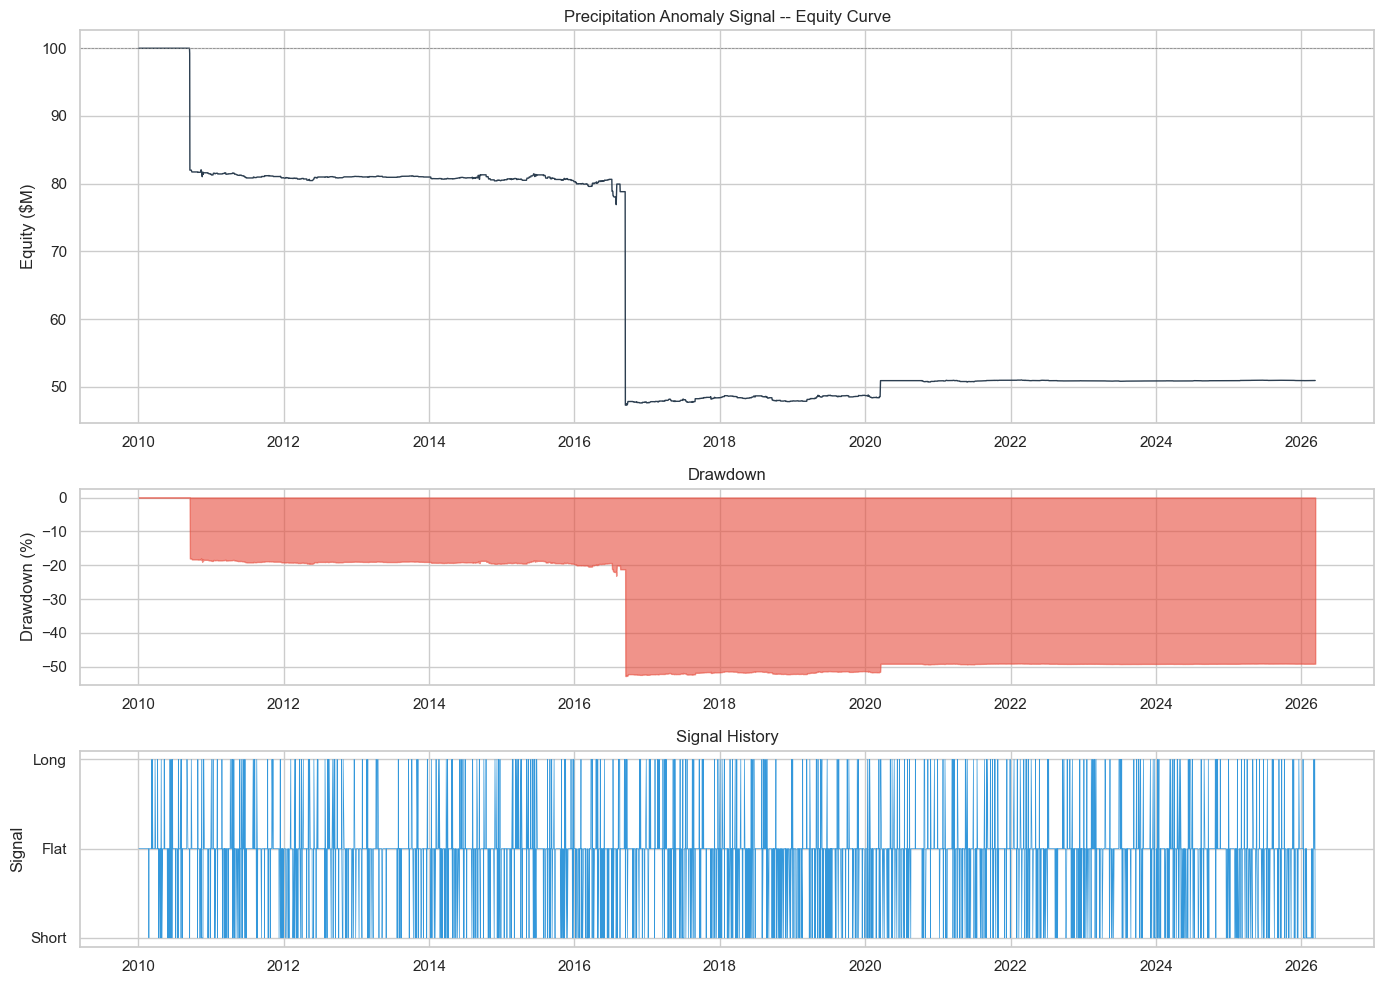

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# Equity curve
axes[0].plot(result.index, result['equity'] / 1e6, linewidth=1, color='#2c3e50')
axes[0].axhline(100, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Equity ($M)')
axes[0].set_title('Precipitation Anomaly Signal -- Equity Curve')

# Drawdown
running_max = result['equity'].cummax()
drawdown_pct = (result['equity'] - running_max) / running_max * 100
axes[1].fill_between(result.index, drawdown_pct, alpha=0.6, color='#e74c3c')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')

# Signal
axes[2].plot(result.index, result['signal'], linewidth=0.5, color='#3498db')
axes[2].set_ylabel('Signal')
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(['Short', 'Flat', 'Long'])
axes[2].set_title('Signal History')

plt.tight_layout()
plt.show()

In [18]:
# Walk-forward check: split into 3 independent periods with FIXED thresholds.
# If the signal only works in one period, it is probably overfit.
periods = [
    ('2010-2014', '2010-01-01', '2014-12-31'),
    ('2015-2019', '2015-01-01', '2019-12-31'),
    ('2020-2025', '2020-01-01', '2025-12-31'),
]

print('=== Walk-Forward (fixed thresholds, no re-optimization) ===')
print(f'{"":<12} {"Sharpe":>8} {"Return %":>10} {"Win Rate":>10} {"Trades":>8} {"Max DD %":>10}')
print('-' * 60)

for label, start, end in periods:
    sub = df.loc[start:end].copy()
    if len(sub) < 100:
        continue
    sub = generate_precip_signal(sub)
    r, tl, s = run_backtest(sub, capital=100_000_000, risk_pct=0.01)
    print(f'{label:<12} {s["sharpe_ratio"]:>8.2f} {s["total_return_pct"]:>10.2f} '
          f'{s["win_rate"]*100:>9.1f}% {s["num_trades"]:>8d} {s["max_drawdown_pct"]:>10.2f}')

=== Walk-Forward (fixed thresholds, no re-optimization) ===
               Sharpe   Return %   Win Rate   Trades   Max DD %
------------------------------------------------------------
2010-2014       -0.50     -19.48      40.7%      241     -19.58
2015-2019       -0.45     -39.46      48.1%      295     -41.94
2020-2025        0.53       4.61      46.9%      320      -0.90


## 8. Comparison Baseline: Momentum and Mean Reversion

To put the weather signal in context, we compare against two standard technical
approaches. These are not expected to perform well on corn -- they are here as
reference points. Momentum and mean reversion features are useful as baselines
and may serve as complementary filters in future work.

In [19]:
# -- Baseline 1: SMA 20/50 Crossover --
sma_df = df[['Close']].copy()
sma_df['sma_20'] = df['Close'].rolling(20).mean()
sma_df['sma_50'] = df['Close'].rolling(50).mean()
sma_df['signal'] = 0
valid = sma_df['sma_20'].notna() & sma_df['sma_50'].notna()
sma_df.loc[valid & (sma_df['sma_20'] > sma_df['sma_50']), 'signal'] = 1
sma_df.loc[valid & (sma_df['sma_20'] < sma_df['sma_50']), 'signal'] = -1

sma_result, sma_trades, sma_stats = run_backtest(sma_df, capital=100_000_000, risk_pct=0.01)

# -- Baseline 2: Mean Reversion (20-day z-score) --
mr_df = df[['Close']].copy()
zscore_mr = (df['Close'] - df['Close'].rolling(20).mean()) / df['Close'].rolling(20).std()
mr_df['signal'] = 0
valid_z = zscore_mr.notna()
mr_df.loc[valid_z & (zscore_mr < -1.5), 'signal'] = 1    # oversold -> long
mr_df.loc[valid_z & (zscore_mr > 1.5), 'signal'] = -1     # overbought -> short

mr_result, mr_trades, mr_stats = run_backtest(mr_df, capital=100_000_000, risk_pct=0.01)

# Comparison table
rows = ['Sharpe', 'Return (%)', 'Win Rate (%)', 'Max DD (%)', 'Trades', 'Profit Factor']
comparison = pd.DataFrame({
    'SMA Crossover': [
        f'{sma_stats["sharpe_ratio"]:.2f}', f'{sma_stats["total_return_pct"]:.2f}',
        f'{sma_stats["win_rate"]*100:.1f}', f'{sma_stats["max_drawdown_pct"]:.2f}',
        sma_stats["num_trades"], f'{sma_stats["profit_factor"]:.2f}',
    ],
    'Mean Reversion': [
        f'{mr_stats["sharpe_ratio"]:.2f}', f'{mr_stats["total_return_pct"]:.2f}',
        f'{mr_stats["win_rate"]*100:.1f}', f'{mr_stats["max_drawdown_pct"]:.2f}',
        mr_stats["num_trades"], f'{mr_stats["profit_factor"]:.2f}',
    ],
    'Precip Anomaly': [
        f'{stats["sharpe_ratio"]:.2f}', f'{stats["total_return_pct"]:.2f}',
        f'{stats["win_rate"]*100:.1f}', f'{stats["max_drawdown_pct"]:.2f}',
        stats["num_trades"], f'{stats["profit_factor"]:.2f}',
    ],
}, index=rows)

print('=== Strategy Comparison ===')
print(comparison.to_string())

=== Strategy Comparison ===
              SMA Crossover Mean Reversion Precip Anomaly
Sharpe                -0.01           0.31          -0.34
Return (%)            -7.06          15.59         -49.07
Win Rate (%)           29.0           58.2           45.5
Max DD (%)           -54.57          -4.96         -52.71
Trades                  100            400            866
Profit Factor          0.71           1.77           0.30


## 9. Feature Catalog Recommendations

Based on the EDA above, here are the features we recommend for the feature store
and the reasoning behind each.

In [20]:
catalog = pd.DataFrame([
    {'Feature': 'precip_7d', 'Category': 'weather',
     'Computation': '7-day rolling sum of daily precipitation',
     'Rationale': 'Short-term accumulation; captures acute weather events',
     'Signal Usefulness': 'Component (too noisy alone)'},
    {'Feature': 'precip_30d', 'Category': 'weather',
     'Computation': '30-day rolling sum of daily precipitation',
     'Rationale': 'Smoothed precipitation trend; captures sustained wet/dry spells',
     'Signal Usefulness': 'Good (basis for anomaly detection)'},
    {'Feature': 'precip_anomaly_30d', 'Category': 'weather',
     'Computation': '30-day rolling z-score of daily precipitation',
     'Rationale': 'Detects extreme deviations from baseline; '
                  'both tails show distinct return patterns in our EDA',
     'Signal Usefulness': 'Primary signal feature'},
    {'Feature': 'temp_max_7d', 'Category': 'weather',
     'Computation': '7-day rolling mean of daily max temperature',
     'Rationale': 'Smoothed temperature; captures heat waves during growing season',
     'Signal Usefulness': 'Enhancer (growing season only)'},
    {'Feature': 'temp_min_7d', 'Category': 'weather',
     'Computation': '7-day rolling mean of daily min temperature',
     'Rationale': 'Tracks overnight lows; relevant for frost/freeze events',
     'Signal Usefulness': 'Component for cold-snap detection'},
    {'Feature': 'temp_range_7d', 'Category': 'weather',
     'Computation': '7-day rolling mean of (temp_max - temp_min)',
     'Rationale': 'Diurnal range; high range can indicate dry continental air',
     'Signal Usefulness': 'Weak standalone; useful in combination'},
    {'Feature': 'sma_20 / sma_50', 'Category': 'momentum',
     'Computation': 'Simple moving averages of close price',
     'Rationale': 'Standard trend indicators; baseline comparison',
     'Signal Usefulness': 'Baseline only'},
    {'Feature': 'zscore_20 / zscore_50', 'Category': 'mean_reversion',
     'Computation': 'Rolling z-score of close price',
     'Rationale': 'Mean reversion detector; useful as regime filter',
     'Signal Usefulness': 'Baseline only'},
])

# Display as a clean table
print(catalog.to_string(index=False, max_colwidth=60))

              Feature       Category                                   Computation                                                    Rationale                      Signal Usefulness
            precip_7d        weather      7-day rolling sum of daily precipitation       Short-term accumulation; captures acute weather events            Component (too noisy alone)
           precip_30d        weather     30-day rolling sum of daily precipitation Smoothed precipitation trend; captures sustained wet/dry ...     Good (basis for anomaly detection)
   precip_anomaly_30d        weather 30-day rolling z-score of daily precipitation Detects extreme deviations from baseline; both tails show...                 Primary signal feature
          temp_max_7d        weather   7-day rolling mean of daily max temperature Smoothed temperature; captures heat waves during growing ...         Enhancer (growing season only)
          temp_min_7d        weather   7-day rolling mean of daily min temperature   

### Summary

**What we found:**
- Linear correlations between weather and returns are weak. This is expected -- the
  relationship is nonlinear. Both drought and flood threaten crop supply.
- Precipitation extremes (both tails of the z-score distribution) are associated with
  positive forward returns. Normal precipitation coincides with flat or negative returns.
- The **30-day precipitation z-score** is the most useful single feature for capturing
  this pattern. It is robust to reasonable threshold variations.
- Temperature adds information during the growing season (May-Sep), particularly at the
  hot extreme, but is weaker than precipitation as a standalone signal.
- Combined drought stress (low precip + high temp) shows promise but has fewer data
  points, making statistical conclusions less certain.
- Standard momentum and mean reversion features underperform on corn, as expected for
  a commodity driven by supply shocks rather than momentum dynamics.

**Feature catalog decisions:**
1. **Weather features** (primary): `precip_7d`, `precip_30d`, `precip_anomaly_30d`,
   `temp_max_7d`, `temp_min_7d`, `temp_range_7d` -- computed per state and aggregated
   as a Corn Belt mean.
2. **Momentum features** (baseline): `sma_20`, `sma_50`, `ema_12`, `ema_26`, `macd`,
   `macd_signal`, `rsi_14` -- standard indicators for comparison and filtering.
3. **Mean reversion features** (baseline): `bollinger_upper`, `bollinger_lower`,
   `zscore_20`, `zscore_50`, `pct_rank_20` -- regime detection and comparison.

**How we arrived here:** Started with raw data, tested the relationship between weather
and prices at multiple time horizons, constructed candidate features, evaluated which
ones carry economically meaningful signal using conditional returns and threshold
sensitivity analysis, then validated with a walk-forward backtest. Features that
did not show signal (dry-streak counts, cumulative anomaly, heat-day counts) were
tested and set aside.